# Credit Card Fraud Detection
- Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Goal: build a model that reliably catches fraudulent transactions despite them being extremely rare.

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

### Data Collection

In [2]:
#Load Dataset
df = pd.read_csv('creditcard.csv')
df['Classes'] = df['Class'].map({0: 'Not Fraud', 1: 'Fraud'})

In [3]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V22       V23       V24       V25       V26  \
0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
2  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642 -0.139097   
3  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.221929   
4 -0.270533  0.817739  ...  0.798278 -0.137458  0.141267 -0.206010  0.502292   

        V27       V28  Amount  C

In [25]:
df.head(5)

# df.info()
# print(df.describe())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Classes
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,Not Fraud
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,Not Fraud
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,Not Fraud
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,Not Fraud
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,Not Fraud


In [24]:
df.shape

(284807, 36)

In [26]:
print("\nClass distribution:")
print(df['Classes'].value_counts())  #Check class balance

#Check for nulls
print("Total missing values:", df.isnull().sum().sum())

#Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

df['Classes'].value_counts(normalize=True) * 100


Class distribution:
Classes
Not Fraud    284315
Fraud           492
Name: count, dtype: int64
Total missing values: 0

Duplicate rows: 1081


Classes
Not Fraud    99.827251
Fraud         0.172749
Name: proportion, dtype: float64

### Preprocessing

In [3]:
#Drop duplicates
df = df.drop_duplicates()

print("New shape:", df.shape)
print("\nClass distribution after dropping duplicates:")
print(df['Classes'].value_counts())
print(df['Classes'].value_counts(normalize=True) * 100)

New shape: (283726, 32)

Class distribution after dropping duplicates:
Classes
Not Fraud    283253
Fraud           473
Name: count, dtype: int64
Classes
Not Fraud    99.83329
Fraud         0.16671
Name: proportion, dtype: float64


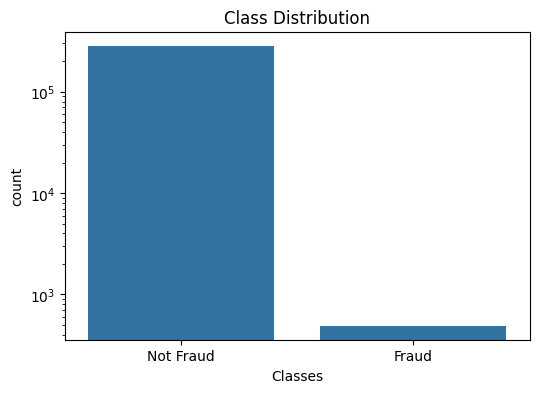

In [4]:
#Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Classes')
plt.title('Class Distribution')
plt.yscale('log')  #log scale needed- fraud bar would be invisible otherwise
plt.show()

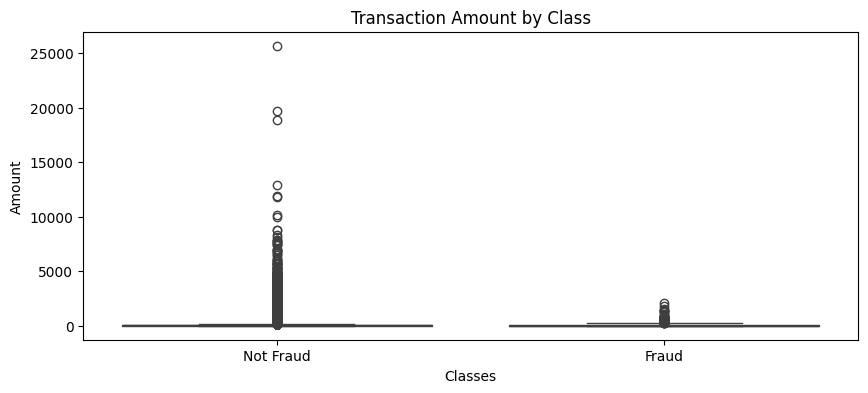

              count        mean         std  min   25%    50%     75%  \
Classes                                                                 
Fraud         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   
Not Fraud  283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46   

                max  
Classes              
Fraud       2125.87  
Not Fraud  25691.16  


In [5]:
#Amount distribution: fraud vs not fraud
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='Classes', y='Amount')
plt.title('Transaction Amount by Class')
plt.show()

print(df.groupby('Classes')['Amount'].describe())

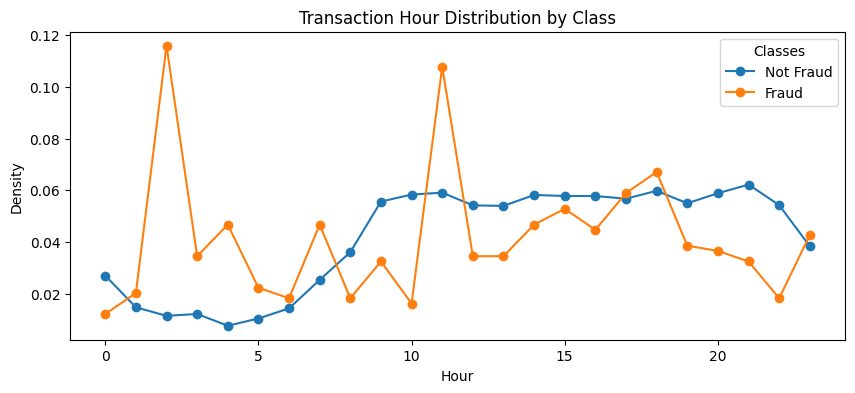

In [12]:
df['Hour'] = (df['Time'] % 86400) // 3600

plt.figure(figsize=(10,4))
for cls in ['Not Fraud', 'Fraud']:
    subset = df[df['Classes'] == cls]
    counts, bins = np.histogram(subset['Hour'], bins=24, range=(0,24), density=True)
    plt.plot(bins[:-1], counts, marker='o', label=cls)
plt.xlabel('Hour')
plt.ylabel('Density')
plt.title('Transaction Hour Distribution by Class')
plt.legend(title='Classes')
plt.show()

In [13]:
fraud_hours = df[df['Classes']=='Fraud']['Hour']
print("Most common fraud hours:", fraud_hours.value_counts().head())

Most common fraud hours: Hour
2.0     57
11.0    53
18.0    33
17.0    29
15.0    26
Name: count, dtype: int64


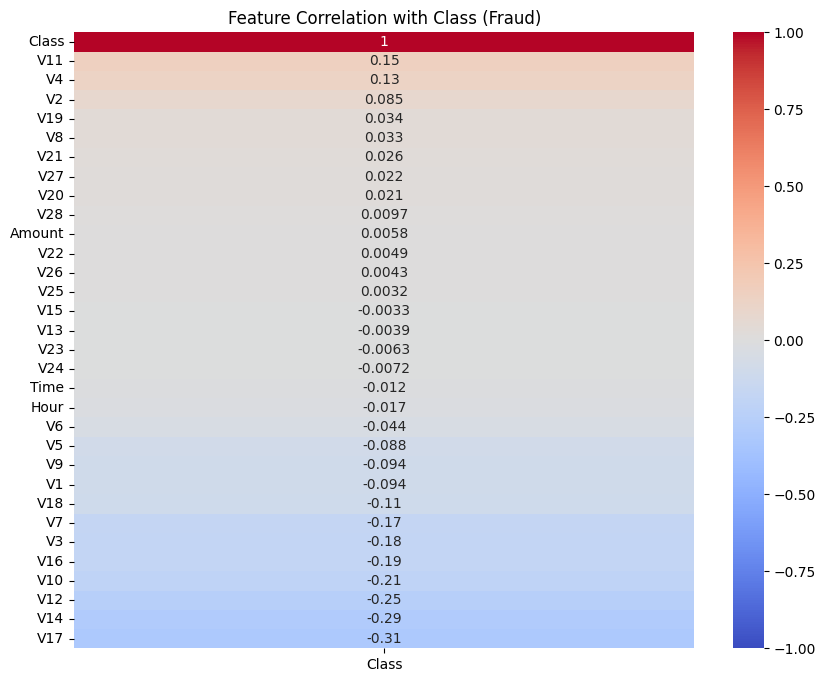

In [8]:
#Correlation with Class
corr = df.drop(columns=['Classes']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Class (Fraud)')
plt.show()

### Feature Scaling

In [6]:
#Log-transform Amount first (reduces skew)
df['Amount_log'] = np.log1p(df['Amount'])  #log1p = log(1+x), handles 0 values safely, new column='Amount_log'

#Scale Amount_log and Time
scaler = StandardScaler()
df[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(df[['Amount_log', 'Time']])

print(df[['Amount', 'Amount_log', 'Amount_scaled', 'Time', 'Time_scaled']].head())

   Amount  Amount_log  Amount_scaled  Time  Time_scaled
0  149.62    5.014760       1.124303   0.0    -1.996583
1    2.69    1.305626      -1.114639   0.0    -1.996583
2  378.66    5.939276       1.682368   1.0    -1.996562
3  123.50    4.824306       1.009339   1.0    -1.996562
4   69.99    4.262539       0.670241   2.0    -1.996541


In [7]:
from sklearn.model_selection import train_test_split

#Features and target
X = df.drop(columns=['Class', 'Classes', 'Amount', 'Amount_log', 'Amount_scaled', 'Time', 'Time_scaled'])
y = df['Class']

#Add back the log-transformed (but not yet scaled) columns
X['Amount_log'] = df['Amount_log']
X['Time'] = df['Time']

#Stratified split (keeps the same fraud/not-fraud ratio in train/test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

#Fit scaler on training data
scaler = StandardScaler()
X_train[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(X_train[['Amount_log', 'Time']]) #calculates mean/std from training data only, then applies it to train.s
X_test[['Amount_scaled', 'Time_scaled']] = scaler.transform(X_test[['Amount_log', 'Time']]) #reuses that SAME mean/std, applies it to test data.

X_train = X_train.drop(columns=['Amount_log', 'Time'])
X_test = X_test.drop(columns=['Amount_log', 'Time'])

print("Train shape:", X_train.shape, "Test shape:", y_train.shape)
print("Train fraud ratio:", y_train.value_counts(normalize=True))
print("Test fraud ratio:", y_test.value_counts(normalize=True))

Train shape: (227845, 30) Test shape: (227845,)
Train fraud ratio: Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Test fraud ratio: Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


### Logistic Regression

Using Class weight parameter: https://www.geeksforgeeks.org/machine-learning/how-does-the-classweight-parameter-in-scikit-learn-work/

In [ ]:
class_weight = {0: 1, 1: 30}  # much gentler than the ~300x 'balanced' would calculate
model = LogisticRegression(solver='lbfgs', max_iter=200, class_weight=class_weight)
model.fit(X_train, y_train)

y_pred_cw2 = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_cw2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cw2, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_cw2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy: 0.9988721672012124

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.63      0.79      0.70        95

    accuracy                           1.00     56746
   macro avg       0.81      0.89      0.85     56746
weighted avg       1.00      1.00      1.00     56746



### SMOTE (training data only)
reference: https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

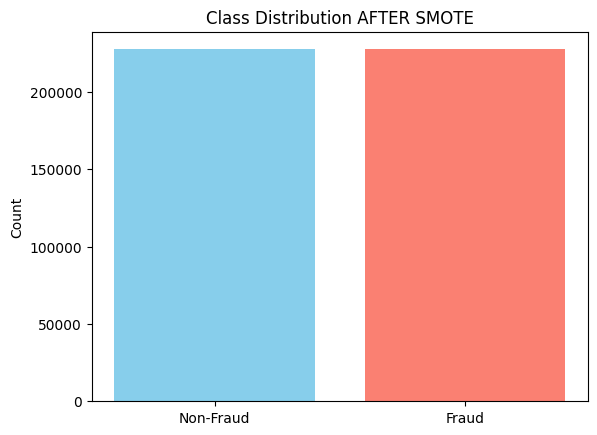

In [8]:
smote = SMOTE(sampling_strategy=1, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [33]:
print("\nClass distribution After Smote:")
print(y_train_sm.value_counts())  #Check class balance


Class distribution After Smote:
Class
0    226602
1    226602
Name: count, dtype: int64


### Logistic Regression After SMOTE

In [31]:
model = LogisticRegression(solver='lbfgs', max_iter=200)
model.fit(X_train_sm, y_train_sm)

y_pred_sm = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sm, target_names=['Not Fraud', 'Fraud']))

Accuracy: 0.9736897754907835

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



### XG Boost
- References: https://www.geeksforgeeks.org/machine-learning/xgboost/

XG Boost on Test
Model Accuracy: 0.9994733330992591

Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.93      0.76      0.83        98

    accuracy                           1.00     56962
   macro avg       0.96      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

XG Boost on Train
Model Accuracy: 0.9995347714455002

Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    227451
       Fraud       0.95      0.77      0.85       394

    accuracy                           1.00    227845
   macro avg       0.97      0.89      0.93    227845
weighted avg       1.00      1.00      1.00    227845



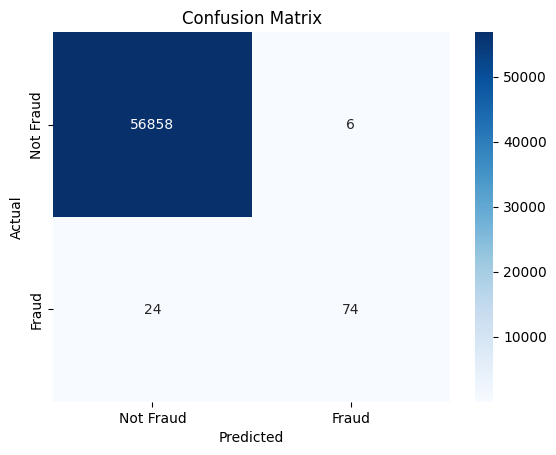

In [21]:
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model = XGBClassifier(**params)
model.fit(X_train, y_train)

#on test
print('XG Boost on Test')
y_pred_xg_test = model.predict(X_test)

accuracy_xg_test = accuracy_score(y_test, y_pred_xg_test)
print("Model Accuracy:", accuracy_xg_test)

print("\nClassification Report")
print(classification_report(y_test, y_pred_xg_test, target_names=['Not Fraud', 'Fraud']))

#on train
print('XG Boost on Train')
y_pred_xg_train = model.predict(X_train)

accuracy_xg_train = accuracy_score(y_train, y_pred_xg_train)
print("Model Accuracy:", accuracy_xg_train)

print("\nClassification Report")
print(classification_report(y_train, y_pred_xg_train, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_xg_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Decision Tree

Decision Tree on Train:
Accuracy: 0.9998

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    227451
       Fraud       0.96      0.91      0.93       394

    accuracy                           1.00    227845
   macro avg       0.98      0.96      0.97    227845
weighted avg       1.00      1.00      1.00    227845


Decision Tree on Test:
Accuracy: 0.9992

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.78      0.78      0.78        98

    accuracy                           1.00     56962
   macro avg       0.89      0.89      0.89     56962
weighted avg       1.00      1.00      1.00     56962



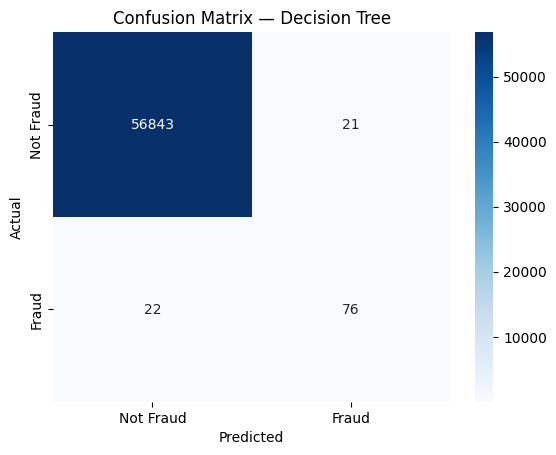

In [26]:
tree_params = None

if tree_params is None:
    tree_params = {
        'criterion': 'gini',
        'max_depth': 10,
        'random_state': 42
    }

model_dt = DecisionTreeClassifier(class_weight={0: 1, 1: 10}, **tree_params)

#Training
model_dt.fit(X_train, y_train)

#Predict + evaluate
y_train_pred = model_dt.predict(X_train)
print("Decision Tree on Train:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}\n")
print(classification_report(y_train, y_train_pred, target_names=['Not Fraud', 'Fraud'], zero_division=0))

y_preds_dt = model_dt.predict(X_test)
print("\nDecision Tree on Test:")
print(f"Accuracy: {accuracy_score(y_test, y_preds_dt):.4f}\n")
print(classification_report(y_test, y_preds_dt, target_names=['Not Fraud', 'Fraud'], zero_division=0))

#Confusion Matrix
cm = confusion_matrix(y_test, y_preds_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Decision Tree')
plt.show()

### Random Forest
- https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/